### Exploratory Analysis of Stress Response, Recovery, and Persistent Expression

### **Purpose**

#### This notebook explores the major biological patterns present in the quality-controlled Arabidopsis thaliana gene-expression dataset. The aim is to move beyond sample-level validation and examine how expression differs across control, stress endpoint, and recovery states, as well as across individual and combined abiotic stress conditions.

#### The analysis focuses on the magnitude and breadth of stress-associated expression changes, the extent to which expression returns toward control after recovery, and the genes that remain persistently different from control. An empirical control-derived response floor is used to support exploratory gene-level comparisons of response, recovery, reversibility, persistence, and substantial direction reversal.

### Particular attention is given to:

#### - differences between endpoint and recovery expression patterns;

#### - variation in response magnitude and recovery across stress conditions;

#### - gene-level reversibility and recovery-state classification;

#### - genes showing persistent expression after recovery;

#### - persistence that is specific to individual stresses or shared across multiple stresses;

#### - the breadth and directional consistency of shared persistence; and

#### - similarities and differences between persistent-gene sets across stress conditions.

#### The purpose of this notebook is exploratory rather than mechanistic. It establishes what expression and recovery patterns are present in the dataset and identifies the gene sets and stress relationships that warrant deeper biological investigation.

#### Functional annotation, pathway-level analysis, and interpretation of the biological roles of shared, high-breadth, and condition-specific persistent genes are reserved for the subsequent biological interpretation notebook.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
DATA_PATH = Path(
    "../data/raw/GSE226105_rLog-Normalized_counts.csv"
)

MANIFEST_PATH = Path(
    "../data/interim/sample_manifest.csv"
)

QC_FLAGS_PATH = Path(
    "../data/interim/sample_qc_flags.csv"
)

In [4]:
df = pd.read_csv(DATA_PATH)

df = df.rename(
    columns={"Unnamed: 0": "gene_id"}
)

sample_manifest = pd.read_csv(
    MANIFEST_PATH
)

qc_flags = pd.read_csv(
    QC_FLAGS_PATH
)

expression_values = df.drop(
    columns=["gene_id"]
)

In [6]:
expression_values.shape

(28775, 57)

In [7]:
sample_manifest.shape

(57, 12)

In [5]:
qc_flags.shape

(57, 3)

### Treatment-Level Expression Profiles

#### Biological replicates are summarized into mean expression profiles for each experimental state and stress condition. 

#### These treatment-level profiles provide a common basis for comparing control, endpoint, and recovery expression patterns across the different stress conditions.

In [8]:
group_profiles = {}

for (state, condition), group in sample_manifest.groupby(
    ["state", "condition"]
):
    samples = group["matrix_column"].tolist()

    group_profiles[(state, condition)] = (
        expression_values[samples].mean(axis=1)
    )

In [9]:
group_expression = pd.DataFrame(
    group_profiles
)

group_expression.index = df["gene_id"]

group_expression.shape

(28775, 19)

In [10]:
group_expression.shape

(28775, 19)

#### 19 because we have 9 endpoint groups, 9 recovery groups and 1 control group.

#### This is important because we have just moved from 57 individual bioogical samples to 19 experimental-state profiles , while preserving the sample-level data separately

#### Conceptually, this will make our central biological questions much easier to express

#### For example :

#### Stress response : Endpoint (gene) - Control (gene)

#### Residual response after recovery : Recovery (gene) - Control (gene)

#### Amount of recovery : Endpoint (gene) - Recovery (gene)

In [11]:
group_expression.columns

MultiIndex([( 'control',                 'control'),
            ('endpoint',                    'cold'),
            ('endpoint',         'cold_high_light'),
            ('endpoint',                 'drought'),
            ('endpoint',                    'heat'),
            ('endpoint',            'heat_drought'),
            ('endpoint', 'heat_drought_high_light'),
            ('endpoint',         'heat_high_light'),
            ('endpoint',           'high_humidity'),
            ('endpoint',              'high_light'),
            ('recovery',                    'cold'),
            ('recovery',         'cold_high_light'),
            ('recovery',                 'drought'),
            ('recovery',                    'heat'),
            ('recovery',            'heat_drought'),
            ('recovery', 'heat_drought_high_light'),
            ('recovery',         'heat_high_light'),
            ('recovery',           'high_humidity'),
            ('recovery',              'high_li

#### Our group expression now contains 19 group-level transcriptomic profiles

#### Pandas has represented the columns as Multiindex which is also very helpful

> ### **Note -** Why MultiIndex is useful
> 
> #### A pandas MultiIndex allows observations to be organized by more than one biological variable at the same time. 
> 
> #### In this dataset, combinations such as experimental state and stress condition naturally define a sample group, so a hierarchical index preserves that structure without collapsing the information into a single label.
> 
> #### This is especially useful in biology because experimental designs are often hierarchical—for example, samples may differ by treatment, time point, tissue, genotype, disease state, or replicate. 
> 
> #### A MultiIndex makes it easier to group, compare, and retrieve data according to these biological factors while keeping their relationships explicit.

### Extract the mean control expression profile as the baseline reference

#### Mean endpoint and recovery expression profiles are centered relative to the control profile for each gene. 

#### These control-relative shifts provide a common reference for comparing the direction and magnitude of transcriptional responses across stress conditions and for examining how much of the endpoint response remains after recovery

In [12]:
control_profile = group_expression[
    ("control", "control")
]

### Separating endpoint and recovery treatment profiles

In [13]:
endpoint_expression = group_expression["endpoint"]

recovery_expression = group_expression["recovery"]

### Calculating gene-level expression shifts relative to the control profile

In [14]:
endpoint_shift = endpoint_expression.subtract(
    control_profile,
    axis=0
)

recovery_shift = recovery_expression.subtract(
    control_profile,
    axis=0
)

In [15]:
endpoint_shift.shape

(28775, 9)

In [16]:
recovery_shift.shape

(28775, 9)

In [17]:
endpoint_shift.columns

Index(['cold', 'cold_high_light', 'drought', 'heat', 'heat_drought',
       'heat_drought_high_light', 'heat_high_light', 'high_humidity',
       'high_light'],
      dtype='object')

In [18]:
recovery_shift.columns

Index(['cold', 'cold_high_light', 'drought', 'heat', 'heat_drought',
       'heat_drought_high_light', 'heat_high_light', 'high_humidity',
       'high_light'],
      dtype='object')

### The two matrices are aligned exactly as intended:

#### endpoint_shift: 28,775 genes × 9 conditions

#### recovery_shift: 28,775 genes × 9 conditions

#### both contain the same nine stress conditions in the same order.

#### So we can now make our first condition-level biological comparison.

### Restricting Shift Profiles to Informative Genes

#### The endpoint and recovery shift matrices were initially calculated for all genes in the processed expression dataset. However, 2,657 genes were identified during quality control as invariant at zero across all 57 samples. 

#### These genes do not contribute any information about differences between control, endpoint, or recovery states.

#### This step therefore identifies the 26,118 informative genes that show at least one non-zero expression value and uses their gene IDs to filter both the endpoint and recovery shift matrices.

#### After this filtering, the two matrices contain only genes that can contribute meaningful variation to downstream comparisons:

#### endpoint_shift_informative → control-relative expression shifts at the stress endpoint

#### recovery_shift_informative → control-relative expression shifts after recovery

#### The purpose is to keep the exploratory analysis focused on genes that actually vary across the experiment while preserving the same informative-gene set established during quality control.

In [19]:
informative_gene_ids = df.loc[
    (expression_values != 0).any(axis=1),
    "gene_id"
]

endpoint_shift_informative = endpoint_shift.loc[
    informative_gene_ids
]

recovery_shift_informative = recovery_shift.loc[
    informative_gene_ids
]

In [20]:
response_magnitude = pd.DataFrame({
    "endpoint_mean_abs_shift":
        endpoint_shift_informative.abs().mean(),

    "recovery_mean_abs_shift":
        recovery_shift_informative.abs().mean(),

    "endpoint_median_abs_shift":
        endpoint_shift_informative.abs().median(),

    "recovery_median_abs_shift":
        recovery_shift_informative.abs().median(),
})

response_magnitude

,endpoint_mean_abs_shift,recovery_mean_abs_shift,endpoint_median_abs_shift,recovery_median_abs_shift
cold,0.274868,0.050476,0.191569,0.031538
cold_high_light,0.390757,0.097284,0.299038,0.069690
drought,0.457738,0.119717,0.285775,0.063300
heat,0.106808,0.049168,0.063380,0.031296
heat_drought,0.654498,0.063022,0.416833,0.035245
heat_drought_high_light,0.290062,0.062086,0.193830,0.037346
heat_high_light,0.095195,0.059712,0.061238,0.036238
high_humidity,0.115541,0.051240,0.064723,0.033400
high_light,0.129623,0.099847,0.081691,0.053001


### **Observations -**

### The strongest endpoint perturbation by mean absolute shift is:

#### `heat_drought` — 0.6545

#### `drought` — 0.4577

#### `cold_high_light` — 0.3908

#### `heat_drought_high_light` — 0.2901

#### `cold` — 0.2749

### The mildest endpoint responses are:

#### `heat_high_light` — 0.0952

#### `heat` — 0.1068

#### `high_humidity` — 0.1155

#### `high_light` — 0.1296

#### Recovery is dramatically smaller

#### For every condition, the recovery mean absolute shift is lower than the endpoint shift.

### A few examples:

#### `heat_drought`: 0.6545 → 0.0630

#### `drought`: 0.4577 → 0.1197

#### `cold`: 0.2749 → 0.0505

#### `cold_high_light`: 0.3908 → 0.0973

#### This is strong descriptive evidence that much of the transcriptomic perturbation has moved back toward the control profile after recovery.

#### For `heat_drought` specifically, the mean residual shift after recovery is only about 9.6% of the endpoint magnitude.

#### That corresponds to roughly a 90% reduction in average absolute displacement.

### Drought retains more:

#### 0.1197 / 0.4577 = 26 % (approx)

#### which means about 74% of the average endpoint displacement has disappeared, but a larger residual remains than for `heat_drought`.

#### That is interesting because drought was already one of the conditions known to retain more residual transcriptomic signal after recovery.

### Mean versus median

#### For `heat_drought`:

#### mean endpoint shift = 0.6545

#### median endpoint shift = 0.4168

#### Both are high.

#### That suggests the response is not driven only by a handful of extreme genes; a substantial fraction of the transcriptome is displaced.

#### For heat:

#### mean = 0.1068

#### median = 0.0634

#### Both are low.

#### So heat appears globally mild at this late endpoint under these conditions.

###  **Insight —** Magnitude of endpoint and recovery transcriptomic shifts

#### Mean absolute expression displacement from control revealed substantial differences in response magnitude among the nine stress conditions. 

#### The strongest endpoint displacement was observed under heat–drought, followed by drought, cold–high-light, heat–drought–high-light, and cold, whereas heat, heat–high-light, high humidity, and high light produced comparatively smaller global shifts. 

#### Median absolute shifts showed a similar ordering, indicating that the stronger conditions produce broadly distributed expression changes rather than being driven only by a small number of extreme-response genes.

#### Across all nine conditions, recovery-state displacement was markedly lower than endpoint displacement, providing descriptive evidence for broad movement of expression profiles back toward the control state after stress removal. 

#### Heat–drought showed a particularly large reduction, with the mean residual shift falling to roughly 10% of the endpoint magnitude, whereas drought retained a larger residual fraction. These values describe relative expression shifts in the rlog-transformed data and are used for exploratory comparison rather than formal differential-expression testing.

#### The heat–drought–high-light condition requires additional caution because its endpoint group mean includes the previously flagged `endpoint_T 2` replicate, whose global expression profile differs substantially from the other two triple-stress replicates. 

#### The resulting endpoint magnitude may therefore underestimate the response represented by T1 and T3. Downstream analyses should include an explicit sensitivity assessment rather than excluding the atypical replicate without justification.

### Endpoint vs recovery transcriptomic displacement

#### For each stress condition, we're comparing:

#### | endpoint - control |

#### with:

#### | recovery−control |

> ### **Note -**
>
>#### large endpoint bar
>#### small recovery bar
>#### ---> strong perturbation followed by substantial return toward control
>
>#### versus:
>
>#### large endpoint bar
>#### still relatively large recovery bar
>#### ---> stronger residual transcriptional displacement

#### What is expected to stand out

####  Based on the table:

#### `heat_drought` should have the tallest endpoint bar but a much smaller recovery bar;

#### `drought` should also have a strong endpoint response but retain a comparatively larger recovery residual;

####  `cold_high_light` should show a substantial endpoint response followed by a strong reduction;

#### the milder conditions such as `heat` and `heat_high_light` should have relatively small endpoint and recovery bars.

### Endpoint and Recovery Response Magnitude Across Stress Conditions

#### This plot compares the average absolute expression shift from control at the stress endpoint and after recovery for each condition. 

#### The stress conditions are arranged from the largest endpoint shift to the smallest.

> ### **Note -**
>
> #### Stress endpoint means the moment when the stress treatment has finished and the plants are measured before recovery begins
>
> #### Control expression = expression in unstressed plants
>
> #### Endpoint expression = expression measured right after the stress treatment
>
> #### Recovery expression = expression measured after the plant had time to recover

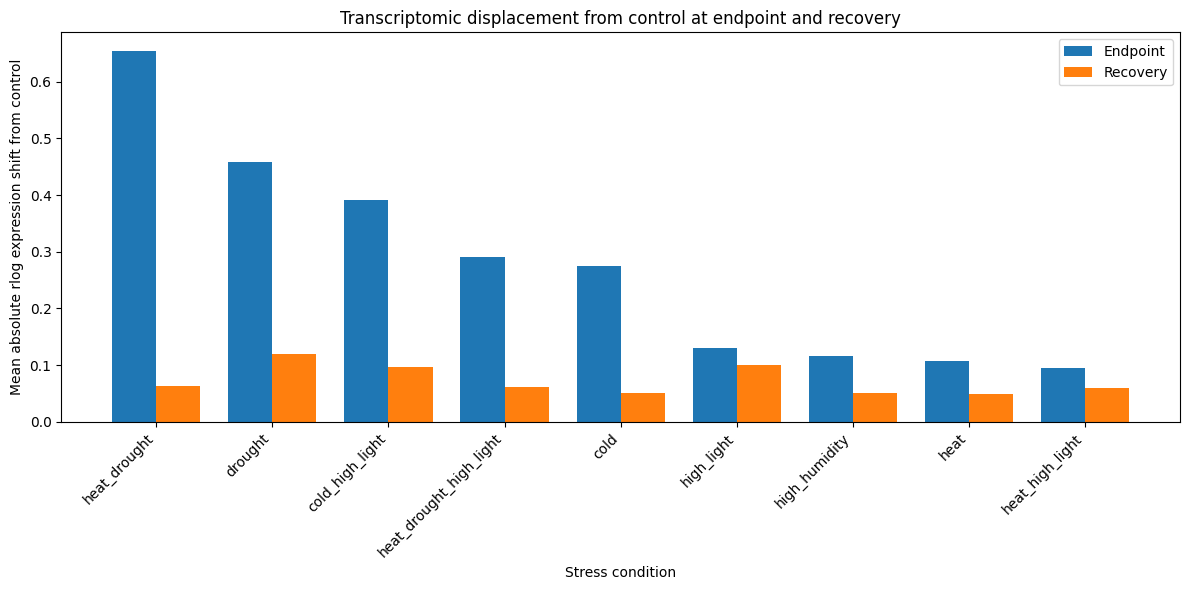

In [21]:
plot_df = (
    response_magnitude[
        [
            "endpoint_mean_abs_shift",
            "recovery_mean_abs_shift"
        ]
    ]
    .sort_values(
        "endpoint_mean_abs_shift",
        ascending=False
    )
)

x = np.arange(len(plot_df.index))
width = 0.38

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    plot_df["endpoint_mean_abs_shift"],
    width,
    label="Endpoint"
)

plt.bar(
    x + width / 2,
    plot_df["recovery_mean_abs_shift"],
    width,
    label="Recovery"
)

plt.xticks(
    x,
    plot_df.index,
    rotation=45,
    ha="right"
)

plt.ylabel("Mean absolute rlog expression shift from control")
plt.xlabel("Stress condition")

plt.title(
    "Transcriptomic displacement from control at endpoint and recovery"
)

plt.legend()

plt.tight_layout()
plt.show()

### Finding the Fraction of the Endpoint Response Remaining After Recovery

#### The recovery shift is divided by the endpoint shift to estimate how much of the original expression difference from control remains after recovery. 

#### A smaller residual fraction means expression has moved closer to control, while a larger value means more of the endpoint difference remains.

In [22]:
response_magnitude["residual_fraction"] = (
    response_magnitude["recovery_mean_abs_shift"]
    /
    response_magnitude["endpoint_mean_abs_shift"]
)

response_magnitude["reduction_fraction"] = (
    1 - response_magnitude["residual_fraction"]
)

In [23]:
response_magnitude[
    [
        "endpoint_mean_abs_shift",
        "recovery_mean_abs_shift",
        "residual_fraction",
        "reduction_fraction"
    ]
].sort_values(
    "residual_fraction"
)

,endpoint_mean_abs_shift,recovery_mean_abs_shift,residual_fraction,reduction_fraction
heat_drought,0.654498,0.063022,0.096290,0.903710
cold,0.274868,0.050476,0.183638,0.816362
heat_drought_high_light,0.290062,0.062086,0.214045,0.785955
cold_high_light,0.390757,0.097284,0.248962,0.751038
drought,0.457738,0.119717,0.261540,0.738460
high_humidity,0.115541,0.051240,0.443476,0.556524
heat,0.106808,0.049168,0.460340,0.539660
heat_high_light,0.095195,0.059712,0.627262,0.372738
high_light,0.129623,0.099847,0.770293,0.229707


### **Insight —** Condition-specific transcriptomic recovery

#### The average expression difference from control decreased after recovery in all nine stress conditions, although the amount of reduction varied considerably between treatments. 

#### Heat–drought produced the largest endpoint shift (~0.654), but its recovery shift fell to only ~0.063. This corresponds to a residual fraction of about 9.6%, the lowest among the nine conditions. 

#### Cold retained about 18.4% of its endpoint shift, while cold–high-light and drought retained approximately 24.9% and 26.2%, respectively.

#### In contrast, high light and heat–high-light retained larger fractions of their endpoint shifts, approximately 77% and 63%. 

#### However, both conditions started with relatively small endpoint shifts, so a large residual fraction does not necessarily mean that a large absolute expression difference remained after recovery. The absolute recovery shift and the residual fraction therefore describe two different aspects of the response and are most useful when considered together.

#### Overall, expression profiles moved closer to control after recovery across all conditions, but both the original size of the stress response and the amount remaining after recovery differed substantially between treatments. 

#### The heat–drought–high-light result should still be interpreted cautiously because its endpoint average includes the previously flagged `endpoint_T 2` replicate.

### Stress Response Size and What Remains After Recovery

#### This analysis compares the size of the expression shift from control at the endpoint with the fraction of that shift that remains after recovery for each stress condition. 

#### The aim is to see whether conditions that produce a stronger initial response also tend to retain more of that response after recovery.

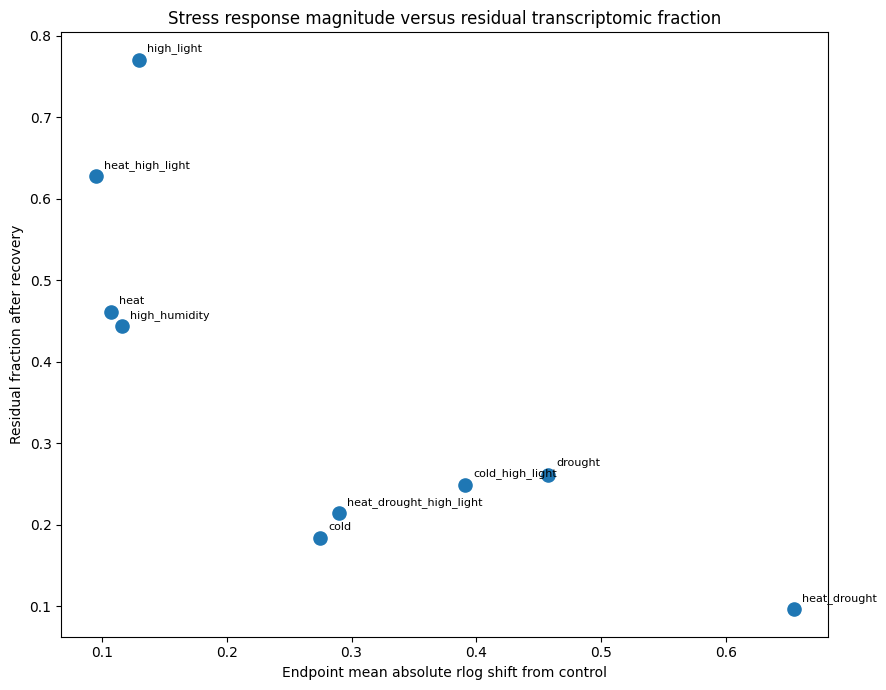

In [24]:
plt.figure(figsize=(9, 7))

plt.scatter(
    response_magnitude["endpoint_mean_abs_shift"],
    response_magnitude["residual_fraction"],
    s=90
)

for condition, row in response_magnitude.iterrows():
    plt.annotate(
        condition,
        (
            row["endpoint_mean_abs_shift"],
            row["residual_fraction"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Endpoint mean absolute rlog shift from control")
plt.ylabel("Residual fraction after recovery")

plt.title(
    "Stress response magnitude versus residual transcriptomic fraction"
)

plt.tight_layout()
plt.show()

### **Insight —** Stress response magnitude and residual expression after recovery

#### Comparing endpoint response magnitude with the residual fraction after recovery shows that the size of the initial stress response and the amount remaining afterward are not the same property. 

#### Heat–drought produced the largest endpoint shift but retained only about 9.6% of that average displacement after recovery. In contrast, high light and heat–high-light produced much smaller endpoint shifts but retained considerably larger fractions, approximately 77% and 63%, respectively.

#### Drought and cold–high-light showed relatively strong endpoint responses with intermediate residual fractions, while cold showed a somewhat smaller endpoint response and a lower remaining fraction.

#### These results show that a stronger initial response does not necessarily mean that a larger proportion of the response will remain after recovery. 

#### The residual fraction should also be considered together with the absolute recovery shift, because a high residual fraction can still correspond to a small remaining expression difference when the original endpoint response was small. 

#### The heat–drought–high-light condition remains subject to the previously identified `endpoint_T 2` QC caveat.

### Estimating Background Expression Variability from Control Samples

#### The three untreated control replicates are compared with one another to estimate the amount of gene-expression variation that exists even without a stress treatment. 

#### This provides an empirical reference for distinguishing very small expression shifts from responses that exceed typical control variability.

In [29]:
control_expression.index[:5]

RangeIndex(start=0, stop=5, step=1)

### Extracting the Control Expression Profiles

In [30]:
control_samples = [
    "CONT 1",
    "CONT 2",
    "CONT 3"
]

control_expression = (
    df
    .set_index("gene_id")
    [control_samples]
)

In [31]:
control_expression.index

Index(['AT1G01010', 'AT1G01020', 'AT1G01030', 'AT1G01040', 'AT1G01046',
       'AT1G01050', 'AT1G01060', 'AT1G01070', 'AT1G01073', 'AT1G01080',
       ...
       'ATMG01320', 'ATMG01330', 'ATMG01340', 'ATMG01350', 'ATMG01360',
       'ATMG01370', 'ATMG01380', 'ATMG01390', 'ATMG01400', 'ATMG01410'],
      dtype='object', name='gene_id', length=28775)

### Keeping Only the Informative Genes

In [ ]:
control_expression = control_expression.loc[
    informative_gene_ids                         # contains the genes that had at least one non-zero expression value somewhere in the experiment
]                                                # keeping only rows whose gene IDs appear in our informative-gene list

In [33]:
control_expression.shape

(26118, 3)

### Measuring Differences Between the Control Replicates

In [34]:
control_pairwise_differences = pd.concat(
    [
        (control_expression["CONT 1"] -
         control_expression["CONT 2"]).abs(),

        (control_expression["CONT 1"] -
         control_expression["CONT 3"]).abs(),

        (control_expression["CONT 2"] -
         control_expression["CONT 3"]).abs(),
    ],
    ignore_index=True
)

### Examining the Distribution of Normal Control Differences

#### We are trying t understand how large are control-to-control differences typically, and how large can they become before becoming unusual

In [35]:
control_pairwise_differences.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

count    78354.000000
mean         0.112791
std          0.135640
min          0.000002
50%          0.073563
75%          0.171386
90%          0.272532
95%          0.342263
99%          0.554173
max          3.032362
dtype: float64

### Defining a Response Floor

In [36]:
response_floor = (
    control_pairwise_differences.quantile(0.95)             # we are using 95th percentile of the control-to-control differences
)

response_floor

np.float64(0.34226272104999966)

### **Insight —** Empirical endpoint-response floor

#### Absolute expression differences among the three control replicates were used to estimate the background level of variability in the rlog-transformed expression matrix. 

#### Across 78,354 gene-level control-pair differences, the median absolute difference was approximately 0.074, while the 90th, 95th, and 99th percentiles were approximately 0.273, 0.342, and 0.554, respectively.

#### 95% of the expression differences we observed between normal control replicates were 0.342 rlog units or smaller.

#### The 95th percentile (~0.342) was selected as an exploratory response floor. Gene–condition pairs with an endpoint shift smaller than this value will not be assigned a proportional Reversibility Index, because very small endpoint responses can make ratio-based recovery measures unstable and difficult to interpret.

#### This threshold is a practical filtering rule based on observed control variability. It is not a statistical significance threshold and does not replace formal differential-expression testing.

### Identifying Genes That Exceed the Endpoint-Response Floor

#### For each stress condition, genes are counted if their absolute endpoint expression shift from control is at least as large as the empirical response floor (~0.342 rlog units). 

#### This shows how many genes respond strongly enough to be carried forward into the proportional recovery analysis.

In [37]:
endpoint_abs_shift = endpoint_shift_informative.abs()

response_eligible = (
    endpoint_abs_shift >= response_floor
)

In [38]:
eligible_summary = pd.DataFrame({
    "eligible_genes": response_eligible.sum(),
    "eligible_fraction": response_eligible.mean()
})

eligible_summary["eligible_percent"] = (
    eligible_summary["eligible_fraction"] * 100
)

eligible_summary.sort_values(
    "eligible_genes",
    ascending=False
)

,eligible_genes,eligible_fraction,eligible_percent
heat_drought,14088,0.539398,53.939812
cold_high_light,12210,0.467494,46.749368
drought,11942,0.457233,45.723256
cold,8915,0.341335,34.133548
heat_drought_high_light,8609,0.329619,32.961942
high_light,1950,0.074661,7.466115
high_humidity,1712,0.065549,6.554866
heat,1310,0.050157,5.015698
heat_high_light,814,0.031166,3.116625


### **Observations -**

#### The proportion of genes exceeding the conservative endpoint-response floor (~0.342) ranges enormously :

#### `heat_drought` : 14,088 genes / 53.9%

#### `cold_high_light` : 12,210 / 46.7%

#### `drought` : 11,942 / 45.7%

#### `cold` : 8,915 / 34.1%

#### `heat_drought_high_light` : 8,609 / 33.0%

#### versus

#### `heat_high_light` : 814 / 3.1%

#### That agrees closely with the condition-level response magnitudes we already observed. So the threshold is not producing an obviously nonsensical result.

### **Insight —** Genes exceeding the endpoint-response floor

#### The number of genes exceeding the control-derived response floor (~0.342 rlog units) differed substantially across stress conditions. 

#### Heat–drought produced the largest number of above-threshold genes, with 14,088 genes (~53.9% of informative genes), followed by cold–high-light (~46.7%), drought (~45.7%), cold (~34.1%), and heat–drought–high-light (~33.0%).

#### In contrast, high light, high humidity, heat, and heat–high-light had much smaller fractions of genes above the threshold, ranging from roughly 3% to 7.5%.

#### This pattern agrees with the earlier response-magnitude analysis: 

#### Conditions with larger overall endpoint shifts also tend to have more genes whose expression changes exceed the control-derived floor. 

#### These genes are considered eligible for the later proportional recovery analysis, but exceeding the threshold does not mean that they are statistically significant differentially expressed genes. 

#### The heat–drought–high-light result should also be interpreted with the previously identified `endpoint_T 2` QC caveat.

### Calculating the Gene-Level Reversibility Index

#### For each gene that exceeded the endpoint-response floor, the recovery shift is compared with the endpoint shift. 

#### The Reversibility Index measures how much smaller the gene's distance from control becomes after recovery.

> ### **Note -** Reversibility Index
> 
> #### The Reversibility Index is used to measure how strongly a gene returns toward its control expression level after recovery.
> 
> #### For each gene:
> 
> #### R = 1 - |Recovery - Control| / |Endpoint - Control|
> 
> #### The denominator represents how far the gene moved away from control at the stress endpoint, while the numerator represents how far it still remains from control after recovery.
> 
> #### The index can be interpreted as:
> 
> #### R close to 1 → expression returned close to the control level.
> 
> #### R close to 0 → recovery expression remains about as far from control as it was at the endpoint.
> 
> #### R below 0 → recovery expression is even farther from control than the endpoint expression.
> 
> #### The index is useful because genes can respond to stress with very different initial magnitudes. By expressing recovery relative to each gene’s own endpoint response, the Reversibility Index allows genes and stress conditions to be compared on a common proportional scale.
> 
> #### The index is calculated only for gene–condition pairs that exceed the endpoint-response floor. This avoids assigning unstable or misleading recovery scores to genes that showed little initial response to stress.
> 
> #### Because the calculation uses absolute distance from control, it does not indicate whether expression is above or below control. Direction reversals are therefore examined separately.

In [45]:
reversibility_index = (
    1
    - (
        recovery_shift_informative.abs()
        / endpoint_shift_informative.abs()
    )
)

reversibility_index = reversibility_index.where(
    response_eligible
)

### Identifying Genes That Cross to the Opposite Side of Control

#### The Reversibility Index measures distance from control but does not preserve direction. 

#### This step separately identifies genes whose endpoint and recovery shifts lie on opposite sides of the control level.

In [46]:
direction_reversal = (
    (endpoint_shift_informative * recovery_shift_informative) < 0
)

direction_reversal = direction_reversal & response_eligible

### Summarizing the Reversibility Index

#### The distribution of Reversibility Index values is summarized for each stress condition to examine how strongly eligible genes tend to return toward control.

In [47]:
reversibility_index.describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
)

,cold,cold_high_light,drought,heat,heat_drought,heat_drought_high_light,heat_high_light,high_humidity,high_light
count,8915.000000,12210.000000,11942.000000,1310.000000,14088.000000,8609.000000,814.000000,1712.000000,1950.000000
mean,0.882691,0.811253,0.755034,0.769142,0.905727,0.848247,0.693977,0.812020,0.335634
std,0.125482,0.216065,0.323944,0.264185,0.141162,0.178342,0.352335,0.193754,0.519880
min,-1.520171,-4.767068,-7.575947,-4.834147,-2.811573,-2.916604,-2.517848,-3.154037,-1.976688
5%,0.669071,0.477058,0.320244,0.368512,0.708883,0.571156,-0.076613,0.491355,-0.609320
25%,0.840151,0.754554,0.703912,0.690688,0.885462,0.802240,0.614550,0.738145,-0.042674
50%,0.917074,0.865010,0.830507,0.832655,0.942080,0.893522,0.805088,0.861435,0.436869
75%,0.964017,0.936928,0.919119,0.922754,0.975064,0.952362,0.905849,0.934294,0.793841
95%,0.993154,0.987481,0.984165,0.986498,0.995691,0.991102,0.987218,0.987424,0.964910
max,0.999996,0.999995,0.999918,0.999998,0.999999,0.999964,0.999797,0.999951,0.999937


### Counting Direction Reversals

#### Direction reversals are counted for each stress condition to determine how often eligible genes cross the control level during recovery.

In [44]:
direction_reversal.sum()

cold                       3454
cold_high_light            6489
drought                    2381
heat                        437
heat_drought               5862
heat_drought_high_light    3381
heat_high_light             269
high_humidity               904
high_light                  359
dtype: int64

#### **Insight —** Gene-level reversibility across stress conditions

#### The Reversibility Index shows that most eligible genes moved substantially closer to their control expression levels after recovery, although the degree of recovery differed between stress conditions. 

#### Median RI values were high for heat–drought (~0.94), cold (~0.92), heat–drought–high-light (~0.89), cold–high-light (~0.87), high humidity (~0.86), drought (~0.83), heat (~0.83), and heat–high-light (~0.81). 

#### In contrast, high light had a much lower median RI of approximately 0.44, meaning that its responsive genes generally retained a larger proportion of their endpoint-level difference from control.

#### Every condition also contained some genes with negative RI values. For these genes, expression was farther from the control level after recovery than it had been at the stress endpoint. These genes should be examined separately because the Reversibility Index alone does not explain why this occurred.

#### Some genes also crossed to the opposite side of the control level during recovery. Direction reversals occurred in roughly 18% to 53% of eligible genes depending on the condition. 

#### However, crossing the control level does not automatically mean a large biological overshoot: a gene may return very close to control and cross it only slightly. Direction reversal therefore needs to be considered together with the size of the remaining recovery shift.

### Identifying Large Residual Expression After Recovery

#### First we detect whether a gene crossed the control level; then we ask whether that crossing was large enough to matter for interpretation

#### Recovery shifts are compared with the same control-derived response floor used for endpoint eligibility. 

#### This identifies genes that remain substantially different from control after recovery.

In [48]:
recovery_residual_large = (
    recovery_shift_informative.abs() >= response_floor
)

recovery_residual_large = (
    recovery_residual_large & response_eligible
)

### Identifying Substantial Direction Reversals

#### A direction reversal is considered substantial only when the recovery expression crosses to the opposite side of control and remains at least one response-floor unit away from the control level.

In [49]:
meaningful_reversal = (
    direction_reversal
    & recovery_residual_large
)

### Summarizing Direction Reversal Patterns

#### Counts and percentages are calculated for both all direction reversals and the subset that remain substantially displaced from control after recovery. 

#### This separates small baseline crossings from larger recovery-associated reversals.

In [50]:
reversal_summary = pd.DataFrame({
    "eligible_genes": response_eligible.sum(),
    "direction_reversals": direction_reversal.sum(),
    "meaningful_reversals": meaningful_reversal.sum(),
})

reversal_summary["direction_reversal_percent"] = (
    reversal_summary["direction_reversals"]
    / reversal_summary["eligible_genes"]
    * 100
)

reversal_summary["meaningful_reversal_percent"] = (
    reversal_summary["meaningful_reversals"]
    / reversal_summary["eligible_genes"]
    * 100
)

reversal_summary

,eligible_genes,direction_reversals,meaningful_reversals,direction_reversal_percent,meaningful_reversal_percent
cold,8915,3454,6,38.743690,0.067302
cold_high_light,12210,6489,346,53.144963,2.833743
drought,11942,2381,89,19.938034,0.745269
heat,1310,437,14,33.358779,1.068702
heat_drought,14088,5862,54,41.609881,0.383305
heat_drought_high_light,8609,3381,31,39.272854,0.360088
heat_high_light,814,269,13,33.046683,1.597052
high_humidity,1712,904,23,52.803738,1.343458
high_light,1950,359,17,18.410256,0.871795


### **Insight —** Distinguishing small baseline crossings from substantial expression reversals

#### Although the initial sign-based analysis showed that roughly 18–53% of eligible genes crossed the control level during recovery, most of these crossings were very small. After requiring the recovery expression to remain at least 0.342 rlog units from control on the opposite side, substantial reversals accounted for less than 3% of eligible genes in every condition.

#### The clearest example is cold: 3,454 genes crossed the control level, but only 6 genes (~0.07%) remained substantially displaced on the opposite side. Cold–high-light showed the largest substantial-reversal fraction, with 346 genes (~2.83%), followed by heat–high-light (~1.60%) and high humidity (~1.34%).

#### This shows why a change in direction alone is not enough to describe recovery. Many genes cross the control level only slightly while returning very close to it. Both the direction of the shift and the size of the remaining difference from control need to be considered together.

#### The central takeaway from this is that a gene can cross past control without actually ending up far from control.

### Classifying Gene-Level Recovery Patterns

#### Each eligible gene is assigned to a recovery category based on two questions: whether its recovery expression remains substantially different from control, and whether it crosses to the opposite side of the control level.

### The three categories are essentially:

#### Recovered ---> after recovery, the gene is back within the normal control-variability range.

#### Persistent, same direction ---> the gene is still substantially different from control and remains on the same side of control as at the endpoint.

#### Substantial reversal ---> the gene crosses to the opposite side of control and remains substantially different from control.

In [54]:
recovery_category = pd.DataFrame(
    index=endpoint_shift_informative.index,
    columns=endpoint_shift_informative.columns,
    dtype="object"                                           # creating an empty recovery-category table
)

for condition in endpoint_shift_informative.columns:         # examining one stress condition at a time

    eligible = response_eligible[condition]                  # genes that responded strongly enough at the endpoint to be included in the recovery analysis

    residual_large = recovery_residual_large[condition]      # genes that are still at least ~ 0.342 rlog units away from control

    reversed_direction = direction_reversal[condition]       # genes that crossed to the opposite side of control during recovery

    recovery_category.loc[                                   # Category 1 - Recovered
        eligible & ~residual_large,
        condition
    ] = "recovered"

    recovery_category.loc[                                   # Category 2 - Persistent in the same direction
        eligible & residual_large & ~reversed_direction,
        condition
    ] = "persistent_same_direction"

    recovery_category.loc[
        eligible & residual_large & reversed_direction,     # Category 3 - Substantial direction reversal
        condition
    ] = "substantial_reversal"

### Counting Genes in Each Recovery Category

In [55]:
recovery_category_counts = pd.DataFrame({
    condition:
        recovery_category[condition].value_counts()
    for condition in recovery_category.columns
}).T.fillna(0).astype(int)

recovery_category_counts

,persistent_same_direction,recovered,substantial_reversal
cold,71,8838,6
cold_high_light,187,11677,346
drought,1240,10613,89
heat,70,1226,14
heat_drought,344,13690,54
heat_drought_high_light,255,8323,31
heat_high_light,72,729,13
high_humidity,28,1661,23
high_light,779,1154,17


### Converting Recovery Categories to Percentages

#### Category percentage = ( genes in category / eligible genes ) x 100 

In [56]:
recovery_category_percent = (
    recovery_category_counts
    .div(eligible_summary["eligible_genes"], axis=0)        # dividing each row by the number of eligible genes belonging to that same stress condition
    * 100
)

recovery_category_percent

,persistent_same_direction,recovered,substantial_reversal
cold,0.796411,99.136287,0.067302
cold_high_light,1.531532,95.634726,2.833743
drought,10.383520,88.871211,0.745269
heat,5.343511,93.587786,1.068702
heat_drought,2.441794,97.174901,0.383305
heat_drought_high_light,2.962016,96.677895,0.360088
heat_high_light,8.845209,89.557740,1.597052
high_humidity,1.635514,97.021028,1.343458
high_light,39.948718,59.179487,0.871795


#### **Observations -** 

#### Across most conditions, the overwhelming majority of genes that exceeded the endpoint-response floor return to within our empirical control-variability range after recovery.

#### The strongest examples are:

#### `cold` : 8,838 / 8,915 (99.14 %) recovered

#### `heat_drought` : 13,690 / 14,088  (97.17 %)

#### `high_humidity` : 1,661 / 1,712  (97.02 %)

#### `heat_drought_high_light` : 8,323 / 8,609  (96.68 %)

#### `cold_high_light` : 11,677 / 12,210  (95.63 %)

#### That means a stress can create a very broad transcriptional response and still be highly reversible. 

#### Heat–drought is the clearest example, it had the largest endpoint-responsive gene set—14,088 genes—yet 97.17% of those genes return to the baseline-like range after recovery.

#### That is a very important biological distinction:

#### response magnitude != response persistence

#### `Drought` shows a different recovery pattern

#### `Drought` has:

#### 10,613 recovered → 88.87%

#### 1,240 persistent in the same direction → 10.38%

#### 89 substantial reversals → 0.75%

#### So although most drought-responsive genes recover, approximately one in ten remains substantially displaced in the same direction.

#### Compare that with heat–drought: persistent same direction = 2.44 %

#### Despite heat–drought having produced a much stronger initial transcriptomic perturbation.

#### `High light` stands out from the other conditions in recovery behavior

#### `high_light` :

#### recovered           :         59.18%

#### persistent_same_direction  :  39.95%

#### substantial_reversal     :      0.87%

#### Among the 1,950 high-light genes that exceeded our endpoint-response floor, approximately 40 % remain substantially displaced in the same direction after recovery. That is dramatically different from the other treatments.

#### `Heat–high-light` is another persistence-rich condition

#### For `heat_high_light`:

#### recovered : 89.56%

#### persistent same direction : 8.85%

#### substantial reversal : 1.60%

#### The eligible set is small—only 814 genes—but among those that did respond, persistent expression is relatively common.

#### So this condition appears to produce a narrower but comparatively persistent expression pattern.

#### `Cold–high-light` is different again

#### `Cold–high-light` has:

#### 95.63% recovered

#### 1.53% persistent

#### 2.83% substantial reversal

#### Its distinctive characteristic is not persistence in the original direction.

#### It is the relatively elevated number of genes that cross control and remain substantially displaced on the opposite side.

#### `Cold` on the other hand shows the strongest overall recovery pattern:

#### 99.14% recovered

#### 0.80% persistent

#### 0.07% substantial reversal

#### Among the 8,915 genes that clearly responded, almost everything returns to our control-like range.

#### That provides a clear contrast with high light:

#### 99.1 % recovered under cold

#### versus

#### 59.2 % recovered under high light

#### even though cold generated a much broader initial response.

### **Insight —** Gene-level recovery patterns across stress conditions

#### Classifying the endpoint-responsive genes showed clear differences in recovery between stress conditions. For most treatments, the majority of eligible genes returned to within the control-derived variability range after recovery. More than 95% were classified as recovered under cold, cold–high-light, heat–drought, heat–drought–high-light, and high humidity.

#### High light was the clearest exception. Only about 59.18% of its eligible genes were classified as recovered, while approximately 39.95% remained substantially different from control in the same direction as the endpoint response. Drought (~10.38%) and heat–high-light (~8.85%) also retained noticeable persistent same-direction subsets.

#### Heat–drought provides an interesting contrast: it produced the largest and broadest endpoint response earlier in the analysis, yet approximately 97.17% of its eligible genes were within the control-derived range after recovery and only about 2.44% remained persistently displaced in the same direction. This shows that a large initial response does not necessarily mean that a large response will remain after recovery.

#### Substantial direction reversals were uncommon overall. Cold–high-light had the largest reversal fraction at approximately 2.83%, while most other conditions were below 2%.

#### These categories are exploratory. Recovered means that the recovery expression fell within the control-derived response floor; it does not mean that expression returned exactly to the control value. Likewise, persistent genes are candidates for further investigation rather than confirmed molecular “scars.” The heat–drought–high-light results should also be interpreted with the previously identified `endpoint_T 2` QC caveat.

### Comparing Recovery Patterns Across Stress Conditions

#### The recovery categories are visualized as percentages so that the overall recovery pattern can be compared across stress conditions, regardless of how many genes were eligible in each condition

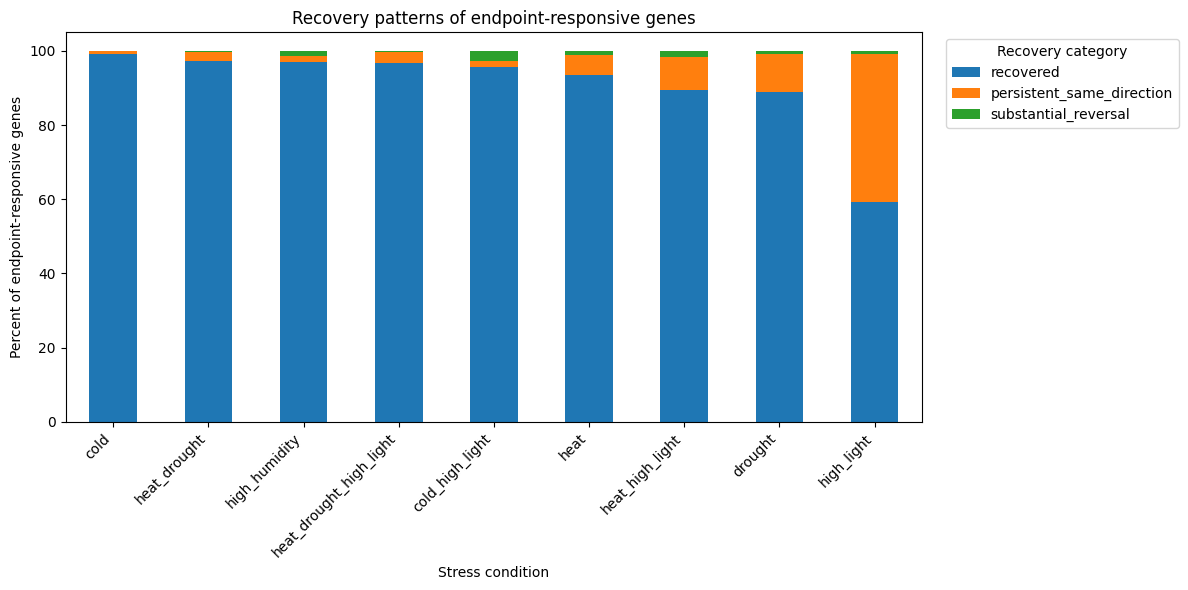

In [59]:
category_order = [
    "recovered",
    "persistent_same_direction",
    "substantial_reversal",
]

plot_categories = (
    recovery_category_percent[
        category_order
    ]
    .sort_values(
        "recovered",
        ascending=False
    )
)

plot_categories.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.ylabel("Percent of endpoint-responsive genes")
plt.xlabel("Stress condition")

plt.title(
    "Recovery patterns of endpoint-responsive genes"
)

plt.legend(
    title="Recovery category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

### **Insight —** Recovery patterns across stress conditions

#### Recovery differs considerably among the stress conditions. In most cases, the majority of endpoint-responsive genes returned to within the control-derived variability range after recovery. 

#### Cold showed the highest recovered fraction at approximately 99.1%, while heat–drought also showed extensive recovery at approximately 97.2%, despite producing the broadest endpoint response.

#### High light showed the clearest contrasting pattern. Only about 59.2% of its responsive genes were classified as recovered, while approximately 39.9% remained substantially displaced from control in the same direction. 

#### Drought and heat–high-light also showed relatively larger persistent fractions, at approximately 10.4% and 8.8%, respectively.

#### Substantial reversals were uncommon across all conditions. Cold–high-light showed the largest reversal fraction, at approximately 2.8%.

#### Overall, the results show that stresses differ not only in how many genes respond initially, but also in what happens to those genes after recovery. A strong initial response does not necessarily lead to greater persistence. The heat–drought–high-light condition should still be interpreted with the previously identified `endpoint_T 2` QC caveat.

### Identifying Persistent Gene Sets for Each Stress Condition

#### For each stress condition, the genes classified as `persistent_same_direction` are collected into a separate set. 

#### This makes it possible to compare persistent genes between conditions and examine whether the same genes remain altered after different stresses

In [60]:
persistent_gene_sets = {}

for condition in recovery_category.columns:

    persistent_gene_sets[condition] = set(
        recovery_category.index[
            recovery_category[condition]
            == "persistent_same_direction"
        ]
    )

### Counting the Number Of Persistent Genes in Each Stress Condition

In [61]:
persistent_set_summary = pd.Series({
    condition: len(genes)
    for condition, genes in persistent_gene_sets.items()
}).sort_values(ascending=False)

persistent_set_summary

drought                    1240
high_light                  779
heat_drought                344
heat_drought_high_light     255
cold_high_light             187
heat_high_light              72
cold                         71
heat                         70
high_humidity                28
dtype: int64

### Measuring Persistence Across Multiple Stress Conditions

In [62]:
persistence_breadth = pd.Series(
    0,
    index=endpoint_shift_informative.index,
    dtype=int
)

for genes in persistent_gene_sets.values():
    persistence_breadth.loc[list(genes)] += 1

In [63]:
persistence_breadth.value_counts().sort_index()

0    24509
1      883
2      350
3      170
4      126
5       48
6       17
7       13
8        2
Name: count, dtype: int64

### **Insight —** Shared versus stress-specific persistence

#### Across the 26,118 informative genes, 1,609 genes were classified as persistent in the same direction after recovery under at least one stress condition. The remaining 24,509 genes were not assigned this persistent classification under any condition.

#### Among the 1,609 persistent genes, 883 (~54.9%) were persistent under only one stress condition, showing that much of the observed persistence is stress-specific. However, 726 genes (~45.1%) were persistent under two or more stresses, indicating that a substantial group of genes shows persistent expression changes across multiple stress conditions.

#### The number of genes decreased as persistence was shared across more stresses: 350 genes were persistent under two conditions, 170 under three, 126 under four, and progressively fewer genes were persistent across five or more conditions. Only two genes met the persistence criteria under eight of the nine stresses, and none did so under all nine.

#### The number of persistent genes also differed considerably between treatments. Drought had the largest persistent gene set with 1,240 genes, followed by high light with 779, whereas several other conditions contained much smaller persistent subsets.

#### Overall, the results suggest that persistent expression after recovery includes both stress-specific genes and a smaller group of genes shared across several stresses. The biological roles of these shared and condition-specific genes will need to be investigated separately. These classifications are exploratory and are based on the control-derived response floor and rlog-transformed group means rather than formal differential-expression testing.

### Direction of Persistent Expression Across Stress Conditions

#### Persistent genes are classified according to whether their expression remains above or below the control level after recovery. 

#### This allows shared persistence across multiple stresses to be separated into directionally consistent and stress-dependent patterns.

In [ ]:
persistent_direction = pd.DataFrame(                           # creating a direction matrix
    0,
    index=endpoint_shift_informative.index,
    columns=endpoint_shift_informative.columns,
    dtype=int
)

for condition in persistent_direction.columns:                 # marking persistent genes as up or down

    persistent_mask = (
        recovery_category[condition]
        == "persistent_same_direction"
    )

    persistent_direction.loc[
        persistent_mask
        & (endpoint_shift_informative[condition] > 0),         # persistent above control ( > 0)
        condition
    ] = 1

    persistent_direction.loc[
        persistent_mask
        & (endpoint_shift_informative[condition] < 0),        # persistent below control ( < 0)
        condition
    ] = -1

### Summarizing Persistence Direction for Each Gene

In [65]:
persistent_direction_summary = pd.DataFrame({
    "n_persistent_conditions":
        (persistent_direction != 0).sum(axis=1),

    "n_persistent_up":
        (persistent_direction == 1).sum(axis=1),

    "n_persistent_down":
        (persistent_direction == -1).sum(axis=1),
})

### Selecting Genes Persistent Across Multiple Stresses

In [66]:
shared_persistent = persistent_direction_summary[
    persistent_direction_summary[
        "n_persistent_conditions"
    ] >= 2
].copy()

### Checking Whether Persistence Has the Same Direction

In [67]:
shared_persistent["direction_consistent"] = (
    (shared_persistent["n_persistent_up"] == 0)
    |
    (shared_persistent["n_persistent_down"] == 0)
)

### Counting Consistent Versus Mixed Genes

In [68]:
shared_persistent[
    "direction_consistent"
].value_counts()

direction_consistent
True     720
False      6
Name: count, dtype: int64

In [69]:
shared_persistent.sort_values(
    "n_persistent_conditions",
    ascending=False
).head(20)

,n_persistent_conditions,n_persistent_up,n_persistent_down,direction_consistent
gene_id,,,,
AT1G80160,8,8,0,True
AT2G43570,8,8,0,True
AT1G09500,7,7,0,True
AT5G13370,7,7,0,True
AT3G56710,7,7,0,True
AT2G19900,7,7,0,True
AT4G24000,7,7,0,True
AT3G49120,7,7,0,True
AT4G12290,7,7,0,True


In [70]:
shared_persistent.sort_values(
    "n_persistent_conditions",
    ascending=False
).tail(20)

,n_persistent_conditions,n_persistent_up,n_persistent_down,direction_consistent
gene_id,,,,
AT1G34750,2,2,0,True
AT1G34420,2,2,0,True
AT5G64370,2,2,0,True
AT5G63790,2,2,0,True
AT1G21390,2,2,0,True
AT3G17700,2,2,0,True
AT3G16720,2,2,0,True
AT3G16670,2,0,2,True
AT3G16410,2,0,2,True


### **Insight —** Directional consistency of shared persistent responses

#### Among the 726 genes classified as persistent under at least two stress conditions, 720 (~99.17%) showed the same direction of persistence across every condition in which they were classified as persistent. Only six genes showed persistent expression above control under some stresses and below control under others.

#### The genes with the broadest persistence were also directionally consistent. Two genes, AT1G80160 and AT2G43570, were persistent under eight of the nine stress conditions, and both remained above control in all eight. Several genes persistent under seven conditions showed the same pattern in the highest-breadth group displayed here.

#### These results show that shared persistence across stresses is usually directionally consistent rather than stress-dependent in sign. 

#### When the same gene remains altered after several different stresses, it almost always remains altered in the same direction.

#### Genes that remain persistently altered across many different stresses are therefore useful candidates for later biological annotation and pathway analysis. However, this exploratory analysis alone does not establish that they represent conserved stress-memory mechanisms or transcriptional scars.

### Direction of Shared Persistent Expression

#### Genes that are persistent across multiple stress conditions and show the same direction in every condition are separated into two groups: those that remain consistently above control and those that remain consistently below control.

In [71]:
shared_consistent = shared_persistent[
    shared_persistent["direction_consistent"]
].copy()

shared_consistent["persistent_direction"] = np.where(
    shared_consistent["n_persistent_up"] > 0,
    "up",
    "down"
)

In [72]:
shared_consistent[
    "persistent_direction"                            # Counting Shared Persistent Genes by Direction
].value_counts()

persistent_direction
up      711
down      9
Name: count, dtype: int64

In [73]:
breadth_direction_summary = pd.crosstab(
    shared_consistent["n_persistent_conditions"],
    shared_consistent["persistent_direction"]
)

breadth_direction_summary

persistent_direction,down,up
n_persistent_conditions,,
2,8,340
3,1,166
4,0,125
5,0,48
6,0,17
7,0,13
8,0,2


### **Insight —** Direction of shared persistent expression

#### Shared persistent expression was overwhelmingly associated with expression remaining above the control level. Among the 720 genes that showed directionally consistent persistence across at least two stress conditions, 711 (~98.75%) were persistently above control, while only 9 (~1.25%) were persistently below control.

#### This difference became even clearer among genes persistent across larger numbers of stresses. Eight of the nine consistently below-control genes were shared across only two stresses, and one was shared across three. In contrast, every directionally consistent gene persistent across four or more stress conditions remained above control.

#### These results show that broadly shared persistence is strongly biased toward expression remaining elevated relative to control rather than remaining suppressed. The high-breadth persistent-above-control genes are therefore particularly interesting candidates for later functional annotation and pathway analysis. Their biological role, however, cannot be determined from the expression pattern alone.

### Identifying the Stress Conditions Associated with Each Persistent Gene

#### For each gene showing persistence under multiple stress conditions, the specific conditions in which persistence occurs are recorded. 

#### This adds biological context to persistence breadth by showing which stresses share the same persistent expression response.

In [74]:
shared_persistent_conditions = {}

for gene in shared_persistent.index:

    shared_persistent_conditions[gene] = [
        condition
        for condition in persistent_direction.columns
        if persistent_direction.loc[gene, condition] != 0
    ]

### Examining Genes with the Broadest Shared Persistence

In [75]:
high_breadth_genes = (
    shared_persistent
    .sort_values(
        "n_persistent_conditions",
        ascending=False
    )
    .head(20)
    .copy()
)

high_breadth_genes["persistent_conditions"] = (
    high_breadth_genes.index.map(
        shared_persistent_conditions
    )
)

high_breadth_genes[
    [
        "n_persistent_conditions",
        "n_persistent_up",
        "n_persistent_down",
        "persistent_conditions",
    ]
]

,n_persistent_conditions,n_persistent_up,n_persistent_down,persistent_conditions
gene_id,,,,
AT1G80160,8,8,0,"[cold, cold_high_light, drought, heat, heat_dr..."
AT2G43570,8,8,0,"[cold, cold_high_light, drought, heat, heat_dr..."
AT1G09500,7,7,0,"[cold_high_light, drought, heat, heat_drought,..."
AT5G13370,7,7,0,"[cold_high_light, drought, heat, heat_drought,..."
AT3G56710,7,7,0,"[cold, drought, heat, heat_drought, heat_droug..."
AT2G19900,7,7,0,"[cold_high_light, drought, heat, heat_drought_..."
AT4G24000,7,7,0,"[cold_high_light, drought, heat, heat_drought,..."
AT3G49120,7,7,0,"[cold, drought, heat, heat_drought, heat_droug..."
AT4G12290,7,7,0,"[cold, cold_high_light, drought, heat_drought,..."


### **Insight —** High-breadth persistent genes

#### The genes with the greatest persistence breadth were consistently above control across the stress conditions in which they were persistent. Two genes, `AT1G80160` and `AT2G43570`, met the persistence criteria under eight of the nine stress conditions, remaining above control in all eight. Several additional genes showed the same pattern across seven conditions.

#### These high-breadth genes are not restricted to persistence under a single type of treatment; their persistent classifications occur across multiple single and combined stress conditions. This makes them particularly interesting candidates for later functional annotation and pathway analysis, where their possible role in a shared post-stress response can be examined.

#### The specific stress conditions in which each gene does not show persistence will also be examined, since those missing conditions may help distinguish broadly shared responses from stress-dependent ones.

### Finding the Missing Stress Conditions

#### For each high-breadth persistent gene, the stress conditions not included in its persistent-condition list are identified. 

#### This helps show where broadly shared persistence breaks down and whether the same stress conditions are repeatedly absent across different genes.

In [76]:
all_conditions = set(
    persistent_direction.columns
)

high_breadth_genes["missing_conditions"] = (
    high_breadth_genes["persistent_conditions"]
    .apply(
        lambda conditions:
        sorted(all_conditions - set(conditions))
    )
)

In [77]:
high_breadth_genes[
    [
        "n_persistent_conditions",
        "n_persistent_up",
        "persistent_conditions",
        "missing_conditions",
    ]
]

,n_persistent_conditions,n_persistent_up,persistent_conditions,missing_conditions
gene_id,,,,
AT1G80160,8,8,"[cold, cold_high_light, drought, heat, heat_dr...",[high_humidity]
AT2G43570,8,8,"[cold, cold_high_light, drought, heat, heat_dr...",[high_humidity]
AT1G09500,7,7,"[cold_high_light, drought, heat, heat_drought,...","[cold, high_humidity]"
AT5G13370,7,7,"[cold_high_light, drought, heat, heat_drought,...","[cold, heat_high_light]"
AT3G56710,7,7,"[cold, drought, heat, heat_drought, heat_droug...","[cold_high_light, high_humidity]"
AT2G19900,7,7,"[cold_high_light, drought, heat, heat_drought_...","[cold, heat_drought]"
AT4G24000,7,7,"[cold_high_light, drought, heat, heat_drought,...","[cold, high_humidity]"
AT3G49120,7,7,"[cold, drought, heat, heat_drought, heat_droug...","[cold_high_light, high_humidity]"
AT4G12290,7,7,"[cold, cold_high_light, drought, heat_drought,...","[heat, high_humidity]"


### **Insight —** Condition membership of high-breadth persistent genes

#### The highest-breadth persistent genes span several different single and combined stress conditions. Notably, both genes persistent across eight of the nine stresses, AT1G80160 and AT2G43570, were persistently above control under every condition except high humidity. High humidity also appeared frequently among the missing conditions of several genes persistent across seven stresses.

#### This suggests that high humidity may participate less often in the broadest shared persistence patterns. However, only 28 genes were classified as persistent under high humidity overall, far fewer than under conditions such as drought or high light. Its frequent absence from high-breadth genes may therefore partly reflect the small size of the high-humidity persistent-gene set rather than a distinct biological difference.

#### Further comparison should account for the overall number of persistent genes available under each condition before concluding that high humidity is specifically underrepresented in shared persistence.

### Condition-Specific and Shared Persistence Across Stresses

#### Persistent genes are summarized separately for each stress condition according to how broadly they are shared across the experiment. 

#### This distinguishes genes that are persistent only under one stress from genes whose persistence is observed across several different stress conditions.

In [ ]:
breadth = persistent_direction_summary[                            # retrieving the persistence breadth of every gene
    "n_persistent_conditions"
]

condition_persistence_summary = []

for condition in persistent_direction.columns:

    persistent_mask = (
        persistent_direction[condition] != 0
    )

    total_persistent = persistent_mask.sum()

    unique_persistent = (
        persistent_mask
        & (breadth == 1)
    ).sum()

    shared_persistent_count = (
        persistent_mask
        & (breadth >= 2)
    ).sum()

    high_breadth_count = (
        persistent_mask
        & (breadth >= 4)
    ).sum()

    condition_persistence_summary.append({
        "condition": condition,
        "total_persistent": total_persistent,
        "unique_to_condition": unique_persistent,
        "shared_with_other_stress": shared_persistent_count,
        "shared_percent": (
            shared_persistent_count
            / total_persistent
            * 100
            if total_persistent > 0
            else np.nan
        ),
        "high_breadth_4plus": high_breadth_count,
        "high_breadth_percent": (
            high_breadth_count
            / total_persistent
            * 100
            if total_persistent > 0
            else np.nan
        ),
    })

condition_persistence_summary = pd.DataFrame(
    condition_persistence_summary
).set_index("condition")

In [79]:
condition_persistence_summary.sort_values(
    "shared_percent",
    ascending=False
)

,total_persistent,unique_to_condition,shared_with_other_stress,shared_percent,high_breadth_4plus,high_breadth_percent
condition,,,,,,
heat_drought_high_light,255,7,248,97.254902,191,74.901961
heat_high_light,72,2,70,97.222222,58,80.555556
heat_drought,344,10,334,97.093023,174,50.581395
heat,70,3,67,95.714286,47,67.142857
cold,71,11,60,84.507042,38,53.521127
high_light,779,152,627,80.487805,197,25.288832
high_humidity,28,9,19,67.857143,11,39.285714
drought,1240,575,665,53.629032,203,16.370968
cold_high_light,187,114,73,39.037433,34,18.181818


### **Insight —** Shared and condition-specific persistent expression

#### The proportion of persistent genes shared with other stresses differed considerably between conditions. 

#### Persistence under heat–drought–high-light, heat–high-light, heat–drought, and heat was highly shared: approximately 96–97% of their persistent genes were also persistent under at least one other stress. 

#### Many of these genes were shared even more broadly, with 50–81% of the persistent genes in these conditions occurring across four or more stresses.

#### Drought and cold–high-light showed much stronger condition-specific persistence. Of the 1,240 drought-persistent genes, 575 were unique to drought, while only about 16.4% were persistent across four or more conditions. 

#### `cold_high_light` was even more condition-specific: 114 of 187 genes were unique to that treatment, and only about 18.2% belonged to the four-or-more-stress group.

#### High light showed a mixture of shared and condition-specific persistence. About 80.5% of its persistent genes overlapped at least one other stress, but only 25.3% were shared across four or more stresses.

#### The normalized comparison also changes how high humidity should be viewed. Although it contained only 28 persistent genes in total, about 67.9% were shared with another stress and 39.3% were persistent across four or more conditions. 

#### Its frequent absence from the highest-breadth gene lists therefore appears to be influenced by its small persistent-gene set rather than indicating complete separation from the shared persistence pattern.

#### Overall, persistent expression after recovery contains both condition-specific genes and genes shared across several stresses, but the balance between these components differs strongly between treatments. These overlap patterns are exploratory and do not by themselves establish common molecular mechanisms.

### Pairwise Overlap of Persistent Genes Across Stress Conditions

#### Each pair of stress conditions is compared to determine how many persistent genes they share. Both the raw number of overlapping genes and the Jaccard similarity are calculated. The raw overlap shows how many genes the two conditions have in common, while the Jaccard score accounts for the different sizes of their persistent-gene sets.

> ### **Note -** Jaccard Similarity
> 
> #### The Jaccard similarity measures how much two sets overlap relative to the total number of unique items found across both sets.
> 
> #### For two gene sets:
> 
> #### Jaccard similarity= total number of unique genes present across the two sets / number of genes shared by both sets​
> 
> #### The score ranges from:
> 
> #### 0 → the two sets share no genes
> 
> #### 1 → the two sets are identical
> 
> #### values between 0 and 1 → partial overlap
> 
> #### In this analysis, each set contains the genes classified as persistent under a particular stress condition. Jaccard similarity therefore tells us how similar the persistent-gene sets of two stress conditions are.
> 
> #### This is useful because different stresses contain very different numbers of persistent genes. A raw overlap count can therefore be misleading. 
>
> #### Sharing 50 genes may represent a large overlap for a condition with 70 persistent genes, but a small overlap for a condition with more than 1,000 persistent genes.
> 
> #### Jaccard similarity accounts for the size of both sets and gives a common scale for comparing stress pairs.
> 
> #### In simple terms: the raw overlap tells us how many persistent genes two stresses share, while Jaccard similarity tells us how similar their overall persistent-gene sets are.

In [80]:
conditions = list(persistent_gene_sets.keys())

persistent_jaccard = pd.DataFrame(
    index=conditions,
    columns=conditions,
    dtype=float
)

persistent_intersection = pd.DataFrame(
    index=conditions,
    columns=conditions,
    dtype=int
)

for condition_1 in conditions:
    for condition_2 in conditions:

        genes_1 = persistent_gene_sets[condition_1]
        genes_2 = persistent_gene_sets[condition_2]

        intersection = len(genes_1 & genes_2)
        union = len(genes_1 | genes_2)

        persistent_intersection.loc[
            condition_1, condition_2
        ] = intersection

        persistent_jaccard.loc[
            condition_1, condition_2
        ] = (
            intersection / union
            if union > 0
            else np.nan
        )

In [81]:
persistent_jaccard.round(3)

,cold,cold_high_light,drought,heat,heat_drought,heat_drought_high_light,heat_high_light,high_humidity,high_light
cold,1.000,0.093,0.032,0.165,0.061,0.116,0.126,0.076,0.059
cold_high_light,0.093,1.000,0.039,0.084,0.054,0.081,0.057,0.029,0.038
drought,0.032,0.039,1.000,0.046,0.242,0.185,0.052,0.011,0.410
heat,0.165,0.084,0.046,1.000,0.070,0.152,0.224,0.077,0.052
heat_drought,0.061,0.054,0.242,0.070,1.000,0.400,0.109,0.022,0.351
heat_drought_high_light,0.116,0.081,0.185,0.152,0.400,1.000,0.189,0.029,0.275
heat_high_light,0.126,0.057,0.052,0.224,0.109,0.189,1.000,0.020,0.077
high_humidity,0.076,0.029,0.011,0.077,0.022,0.029,0.020,1.000,0.015
high_light,0.059,0.038,0.410,0.052,0.351,0.275,0.077,0.015,1.000


In [82]:
persistent_intersection

,cold,cold_high_light,drought,heat,heat_drought,heat_drought_high_light,heat_high_light,high_humidity,high_light
cold,71.0,22.0,41.0,20.0,24.0,34.0,16.0,7.0,47.0
cold_high_light,22.0,187.0,53.0,20.0,27.0,33.0,14.0,6.0,35.0
drought,41.0,53.0,1240.0,58.0,309.0,233.0,65.0,14.0,587.0
heat,20.0,20.0,58.0,70.0,27.0,43.0,26.0,7.0,42.0
heat_drought,24.0,27.0,309.0,27.0,344.0,171.0,41.0,8.0,292.0
heat_drought_high_light,34.0,33.0,233.0,43.0,171.0,255.0,52.0,8.0,223.0
heat_high_light,16.0,14.0,65.0,26.0,41.0,52.0,72.0,2.0,61.0
high_humidity,7.0,6.0,14.0,7.0,8.0,8.0,2.0,28.0,12.0
high_light,47.0,35.0,587.0,42.0,292.0,223.0,61.0,12.0,779.0


### **Observations -** 

#### The strongest pairwise similarities by Jaccard are:

#### drought <--> high light: J = 0.410, sharing 587 genes

#### heat–drought <--> heat–drought–high-light: J = 0.400, sharing 171 genes

#### heat–drought <--> high light: J = 0.351, sharing 292 genes

#### heat–drought–high-light <--> high light: J = 0.275, sharing 223 genes

#### drought <--> heat–drought: J = 0.242, sharing 309 genes

#### heat <--> heat–high-light: J = 0.224, sharing 26 genes

### **Insight —** Pairwise similarity of persistent gene sets

#### Pairwise comparison showed substantial differences in how strongly the persistent-gene sets of different stress conditions overlapped. The greatest Jaccard similarity was observed between drought and high light (J = 0.410, 587 shared genes), followed by heat–drought and heat–drought–high-light (J = 0.400, 171 shared genes). Other relatively strong similarities included heat–drought with high light (J = 0.351) and heat–drought–high-light with high light (J = 0.275).

#### Some combined treatments showed greater similarity to one component stress than to another. For example, the persistent-gene set under heat–high-light was more similar to heat (J = 0.224) than to high light (J = 0.077). In contrast, cold–high-light showed relatively low similarity to both cold (J = 0.093) and high light (J = 0.038).

#### These results show that persistent expression after recovery is shared to different degrees between particular stress pairs. Some conditions retain many of the same genes, whereas others contain more distinct persistent-gene sets. These pairwise overlaps are descriptive and do not by themselves establish mechanistic similarity or additive/non-additive interactions between stresses.

### Heatmap of Pairwise Persistent-Gene Similarity

#### The pairwise Jaccard similarity matrix is visualized as a heatmap to make similarities between persistent-gene sets easier to compare across stress conditions. 

#### Higher Jaccard values indicate greater overlap between the persistent genes associated with two conditions.

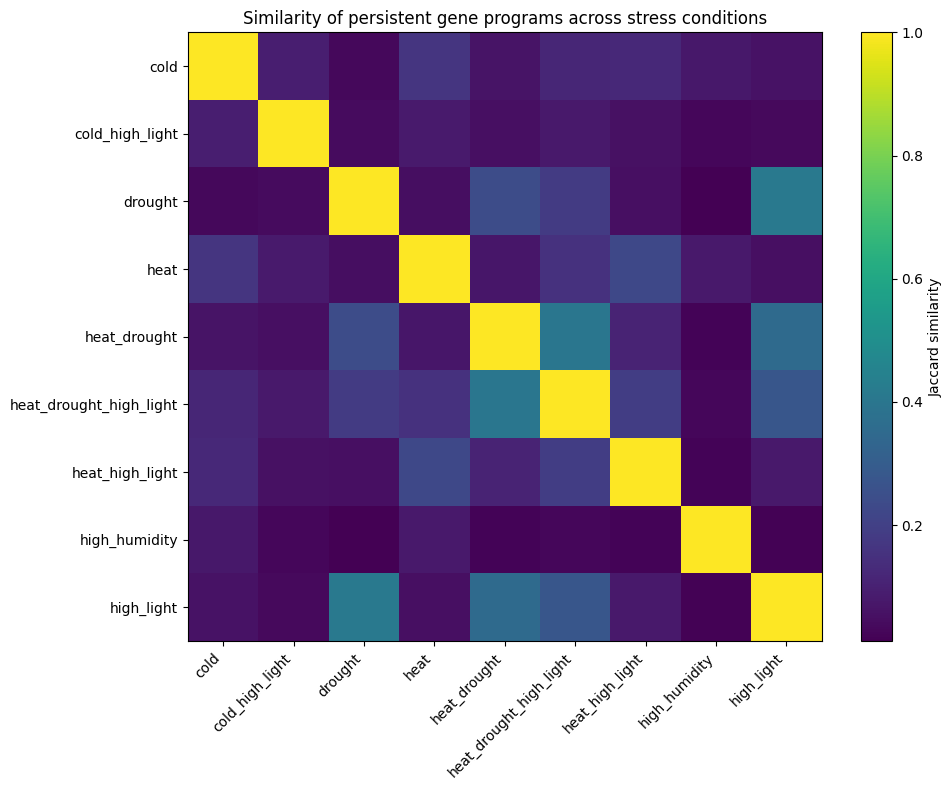

In [83]:
plt.figure(figsize=(10, 8))

plt.imshow(
    persistent_jaccard,
    aspect="auto"
)

plt.colorbar(
    label="Jaccard similarity"
)

plt.xticks(
    range(len(persistent_jaccard.columns)),
    persistent_jaccard.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(persistent_jaccard.index)),
    persistent_jaccard.index
)

plt.title(
    "Similarity of persistent gene programs across stress conditions"
)

plt.tight_layout()
plt.show()

### **Observations -**

#### drought <--> high_light is one of the strongest relationships.

#### heat_drought <--> heat_drought_high_light is also very strong.

#### heat_drought and the triple stress both show substantial similarity with high_light.

#### heat_high_light shares a more noticeable program with heat and the triple stress than with high light itself.

#### cold_high_light does not strongly resemble either cold or high light in its persistent program.

#### high_humidity has weak similarity to essentially every other condition.

### **Insight —** Pairwise similarity of persistent gene sets

#### The Jaccard-similarity heatmap shows that the overall composition of persistent-gene sets differs considerably across stress conditions. The greatest pairwise similarity was observed between drought and high light (J = 0.410) and between heat–drought and heat–drought–high-light (J = 0.400). Relatively high similarity was also observed between heat–drought and high light (J = 0.351) and between heat–drought–high-light and high light (J = 0.275).

#### Other stress pairs showed substantially lower whole-set similarity. For example, cold–high-light had relatively low Jaccard similarity with both cold (J = 0.093) and high light (J = 0.038).

#### Jaccard similarity should be interpreted cautiously when persistent-set sizes differ greatly between conditions. A low Jaccard value does not necessarily mean that a small condition shares few of its genes with a larger condition, because the score considers the total number of unique genes across both sets. The heatmap therefore describes overall set similarity, rather than the fraction of one condition's persistent genes contained within another.

### Hierarchical Clustering of Persistent-Gene Sets

#### Pairwise Jaccard similarities are converted into distances and used for hierarchical clustering of the stress conditions. 

#### This groups conditions according to the similarity of their persistent-gene sets, allowing broader patterns of relatedness among stresses to be visualized.

In [84]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram

persistent_distance = (
    1 - persistent_jaccard
)

np.fill_diagonal(
    persistent_distance.values,
    0
)

In [85]:
persistent_distance_condensed = squareform(
    persistent_distance.values
)

In [86]:
condition_linkage = linkage(
    persistent_distance_condensed,
    method="average"
)

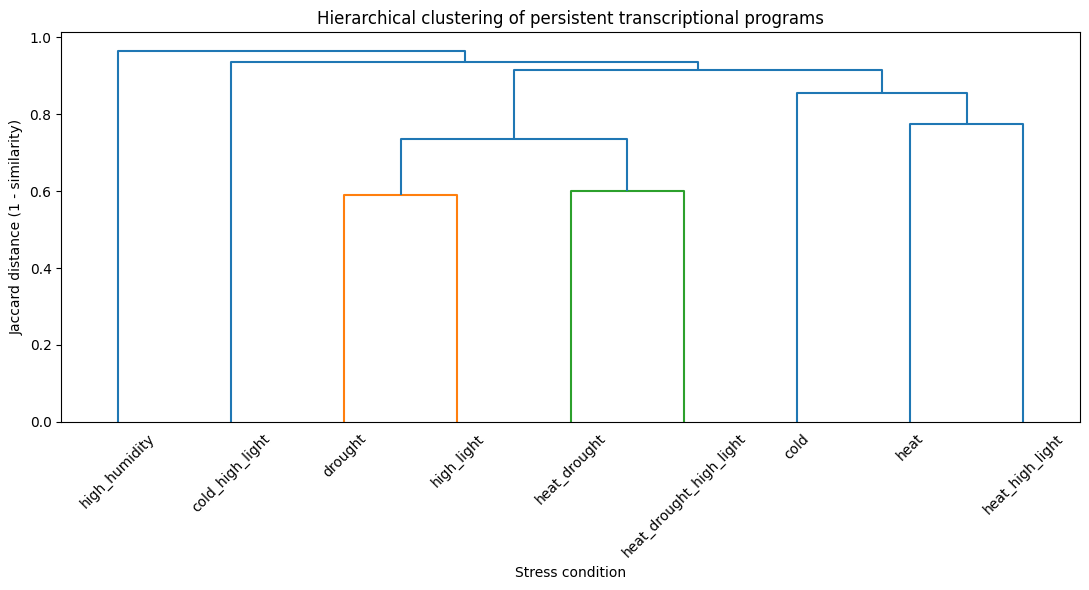

In [87]:
plt.figure(figsize=(11, 6))

dendrogram(
    condition_linkage,
    labels=persistent_distance.index.tolist(),
    leaf_rotation=45,
    leaf_font_size=10
)

plt.ylabel("Jaccard distance (1 - similarity)")
plt.xlabel("Stress condition")

plt.title(
    "Hierarchical clustering of persistent transcriptional programs"
)

plt.tight_layout()
plt.show()

### **Observations -**

#### Drought + high light join first, at a Jaccard distance of about 0.59 because their similarity was 0.410.

#### Heat–drought + heat–drought–high-light form another close pair, at about 0.60.

#### Those two pairs then join into a larger group. So drought, high light, heat–drought, and the triple stress have relatively similar persistent-gene sets compared with many of the other conditions.

#### Heat + heat–high-light form another pair, but they join at a substantially larger distance (~0.78), so their similarity is weaker than the first two pairs.

#### Cold subsequently joins the heat/heat–high-light side.

#### Cold–high-light joins the rest only at a relatively large distance, meaning its overall persistent-gene set is comparatively different.

#### High humidity joins last, meaning it has the greatest Jaccard distance from the other groups overall. But, as we already learned, this must be interpreted cautiously because high humidity has only 28 persistent genes.

### **Insight —** Hierarchical clustering of persistent gene sets

#### Hierarchical clustering of Jaccard distances organized the stress conditions according to the similarity of their persistent-gene sets. 

#### Drought and high light formed the closest pair, while heat–drought and heat–drought–high-light formed a second closely related pair. These pairs subsequently joined into a broader group, showing relatively similar persistent-gene composition across these four conditions.

#### Heat and heat–high-light formed another pair, although at a greater distance, indicating weaker overall similarity. 

#### Cold–high-light remained comparatively distinct from both cold and high light, while high humidity joined the remaining conditions only at a large distance.

#### The clustering provides a compact visualization of the relationships already captured by the Jaccard similarity matrix. Because Jaccard similarity is affected by differences in persistent-set size, particularly for conditions such as high humidity, these clusters describe similarity in gene-set composition and should not by themselves be interpreted as evidence of common regulatory mechanisms or additive/non-additive stress interactions.

### **Exploratory Analysis Summary**

#### Exploratory analysis was performed on the processed rlog-transformed Arabidopsis thaliana expression matrix after completion of structural and sample-level quality control. All 57 samples were retained, with `endpoint_T 2` carried forward as an explicitly flagged atypical heat–drought–high-light replicate and `endpoint_HEAT DROUGHT 3` retained as a sample showing elevated within-treatment variability.

#### Biological replicates were summarized into 19 group-level expression profiles comprising one control profile, nine endpoint stress profiles, and nine corresponding recovery profiles. For each stress condition, endpoint and recovery expression shifts were calculated relative to the control profile. These values represent differences on the rlog-transformed expression scale and are therefore treated as descriptive expression shifts rather than formal log2 fold changes.

### Stress-response magnitude

#### The nine stresses differed substantially in the magnitude and breadth of their endpoint expression responses. Heat–drought produced the largest mean absolute displacement from control, followed by drought, cold–high-light, heat–drought–high-light, and cold. Heat, heat–high-light, high humidity, and high light produced considerably smaller average endpoint shifts.

#### An empirical response floor of approximately 0.342 rlog units was derived from the 95th percentile of absolute expression differences among control biological replicates. This threshold was used only to stabilize exploratory proportional-recovery analyses and does not represent a statistical differential-expression significance criterion.

#### The proportion of informative genes exceeding this endpoint-response floor varied markedly among stresses. Heat–drought produced the broadest response, with 14,088 genes (~53.9%) exceeding the threshold, followed by cold–high-light (~46.7%), drought (~45.7%), cold (~34.1%), and heat–drought–high-light (~33.0%). Heat–high-light, heat, high humidity, and high light produced substantially narrower endpoint-responsive gene sets.

### Recovery and reversibility

#### All nine conditions showed lower mean absolute expression displacement after recovery than at endpoint, indicating broad movement toward the control state after stress removal. However, the extent of recovery differed strongly among conditions. Heat–drought produced the largest endpoint response but retained only approximately 9.6% of its average endpoint displacement after recovery. Drought retained approximately 26.2%, whereas high light retained approximately 77% of its smaller initial displacement.

#### These results show that endpoint response magnitude and persistence are distinct properties. A strong stress response does not necessarily lead to a strongly persistent recovery state.

#### A gene-level Reversibility Index was calculated only for genes whose endpoint response exceeded the empirical response floor:

**RI = 1 -|Recovery-Control| / |Endpoint-Control|**

#### Most eligible genes showed positive and often high RI values, indicating substantial movement toward control. Median reversibility was especially high under heat–drought and cold, whereas high light showed substantially lower proportional recovery among its responsive-gene subset.

#### Raw sign changes across the control baseline were initially common, but most involved small crossings close to the control level. Requiring the recovery residual itself to exceed the empirical response floor greatly reduced the apparent reversal signal. These stronger events were therefore classified as substantial reversals.

### Recovery-state classification

#### Endpoint-responsive genes were classified into three exploratory recovery categories:

#### `recovered` — the recovery residual fell below the empirical response floor;

#### `persistent_same_direction` — expression remained substantially displaced from control in the same direction as the endpoint response;

#### `substantial_reversal` — expression crossed the control baseline and remained substantially displaced in the opposite direction.

#### Recovery dominated most stress conditions. Approximately 99.1% of cold-responsive genes, 97.2% of heat–drought genes, 97.0% of high-humidity genes, 96.7% of heat–drought–high-light genes, and 95.6% of cold–high-light genes were classified as recovered.

#### High light showed the clearest contrasting pattern: only approximately 59.2% of responsive genes recovered, while 39.9% remained persistently displaced in the same direction. Drought and heat–high-light also retained notable persistent fractions of approximately 10.4% and 8.8%, respectively.

#### Cold–high-light showed relatively little same-direction persistence but the highest substantial-reversal fraction (~2.8%). Recovery-state behavior therefore differed not only in magnitude but also in the relative balance between recovery, persistence, and reversal.

### Shared versus condition-specific persistence

#### Across the 26,118 informative genes, 1,609 genes were persistently displaced in at least one stress condition. Of these, 883 (~54.9%) were persistent in only one stress, indicating a substantial condition-specific component, while 726 (~45.1%) were persistent across two or more conditions.

#### Persistence breadth declined progressively with the number of stresses: 350 genes were persistent in two conditions, 170 in three, 126 in four, 48 in five, 17 in six, 13 in seven, and two genes in eight of the nine conditions. No gene was persistent in all nine stresses.

#### Shared persistence was overwhelmingly directionally consistent. Of the 726 genes persistent across at least two stresses, 720 (~99.2%) maintained the same direction everywhere they were persistent. Among these directionally consistent shared genes, 711 (~98.8%) remained above control and only nine remained below control. Every directionally consistent gene persistent across four or more stresses remained above control.

#### Two genes, `AT1G80160` and `AT2G43570`, were persistently above control in eight of the nine conditions, with high humidity being the single missing condition for both. These genes are therefore strong candidates for later functional investigation of broadly shared post-stress persistence, although their biological roles cannot be inferred from expression overlap alone.

### Condition-specific and shared persistence

#### The composition of persistent-gene sets differed substantially among stress conditions. More than 95% of persistent genes under heat, heat–drought, heat–high-light, and heat–drought–high-light were also persistent under at least one additional stress, indicating that most persistent genes in these conditions were shared rather than unique to a single treatment.

#### Drought contained a much larger condition-specific component: 575 of 1,240 persistent genes were unique to drought. Cold–high-light was even more condition specific, with 114 of 187 persistent genes unique to that treatment.

#### Pairwise Jaccard analysis showed the greatest whole-set similarity between drought and high light and between heat–drought and heat–drought–high-light. 

#### Heat–drought also showed relatively high similarity with high light and with the triple-stress condition. By contrast, cold–high-light showed relatively low Jaccard similarity with both cold and high light, indicating that its persistent-gene set differs substantially in composition from those of the corresponding single-stress treatments.

#### Hierarchical clustering of Jaccard distances grouped drought, high light, heat–drought, and heat–drought–high-light into a broader branch, while heat and heat–high-light formed another pair. Cold–high-light joined the remaining conditions only at a comparatively large distance. High humidity also joined at a large distance, although this result should be interpreted cautiously because only 28 genes were classified as persistent under high humidity.

#### These pairwise and clustering analyses describe similarities in persistent-gene-set composition. They do not by themselves establish common regulatory mechanisms or additive versus non-additive interactions between combined stresses.

### Overall exploratory conclusion

#### The exploratory analysis indicates that the stress conditions differ along at least three separable dimensions:

#### endpoint response magnitude, degree of recovery, and the pattern of persistent expression after recovery.

#### Strong endpoint responses can be highly reversible, as illustrated by heat–drought, whereas comparatively smaller responses can retain large persistent fractions, as observed under high light. Persistent expression after recovery contains both condition-specific genes and genes shared across several different stresses, with the balance between these components varying substantially among treatments.

#### The broadly shared persistent genes were also strikingly directionally consistent, with the great majority remaining above control wherever persistence was observed. In contrast, conditions such as drought and cold–high-light contained substantial sets of genes whose persistence was restricted to that particular treatment.

#### These findings remain exploratory. They are derived from rlog-transformed group-level expression profiles and an empirical control-based response floor rather than formal count-based differential-expression testing. 

#### The next phase will focus on biological annotation and functional interpretation of shared, high-breadth, and condition-specific persistent gene sets, followed later by formal statistical validation and comparison with published differential-expression and enrichment results.

### Saving only the derived objects we need as a CSV file in exploratory_analysis folder in data/interim

In [88]:
EXPLORATORY_DIR = Path(
    "../data/interim/exploratory_analysis"
)

EXPLORATORY_DIR.mkdir(
    parents=True,
    exist_ok=True
)

### Condition-level Response Summary

In [89]:
response_magnitude.to_csv(
    EXPLORATORY_DIR / "condition_response_magnitude.csv"
)

### Recovery-Category Summaries

In [90]:
recovery_category_counts.to_csv(
    EXPLORATORY_DIR / "recovery_category_counts.csv"
)

recovery_category_percent.to_csv(
    EXPLORATORY_DIR / "recovery_category_percent.csv"
)

### Condition Persistence Architecture

In [91]:
condition_persistence_summary.to_csv(
    EXPLORATORY_DIR / "condition_persistence_summary.csv"
)

### Pairwise Persistent-Program Relationships

In [92]:
persistent_jaccard.to_csv(
    EXPLORATORY_DIR / "persistent_jaccard_similarity.csv"
)

persistent_intersection.to_csv(
    EXPLORATORY_DIR / "persistent_gene_intersections.csv"
)

### Creating a Gene-level Persistent Table

In [93]:
persistent_gene_records = []

for condition in persistent_direction.columns:

    persistent_genes = persistent_direction.index[
        persistent_direction[condition] != 0
    ]

    for gene in persistent_genes:

        persistent_gene_records.append({
            "gene_id": gene,
            "condition": condition,

            "direction": (
                "up"
                if persistent_direction.loc[
                    gene, condition
                ] == 1
                else "down"
            ),

            "endpoint_shift":
                endpoint_shift_informative.loc[
                    gene, condition
                ],

            "recovery_shift":
                recovery_shift_informative.loc[
                    gene, condition
                ],

            "reversibility_index":
                reversibility_index.loc[
                    gene, condition
                ],

            "persistence_breadth":
                persistent_direction_summary.loc[
                    gene,
                    "n_persistent_conditions"
                ],
        })

persistent_gene_table = pd.DataFrame(
    persistent_gene_records
)

In [94]:
persistent_gene_table.head()

,gene_id,condition,direction,endpoint_shift,recovery_shift,reversibility_index,persistence_breadth
0,AT1G02920,cold,up,0.945919,1.038718,-0.098105,6
1,AT1G07050,cold,up,2.539818,0.400763,0.842208,2
2,AT1G09350,cold,up,1.762854,0.449332,0.745111,1
3,AT1G09932,cold,up,0.400360,0.398219,0.005349,4
4,AT1G10070,cold,up,0.542044,0.355872,0.343464,6


### Saving the Gene-level Persistent Table as a CSV

In [95]:
persistent_gene_table.to_csv(
    EXPLORATORY_DIR / "persistent_gene_table.csv",
    index=False
)

### Saving the High-breadth Candidates Separately

In [96]:
high_breadth_output = (
    persistent_direction_summary[
        persistent_direction_summary[
            "n_persistent_conditions"
        ] >= 4
    ]
    .copy()
)

high_breadth_output.to_csv(
    EXPLORATORY_DIR
    / "high_breadth_persistent_genes.csv"
)

### Complete Gene Recovery Categories

In [97]:
recovery_category.to_csv(
    EXPLORATORY_DIR
    / "gene_recovery_categories.csv"
)